# Quark Benchmark Validation

This notebook uses only package helpers from `quarkConstraints.validation`.
It summarizes the benchmark fit and the `r`-sweep data that the pytest layer validates.

In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd().resolve().parents[0]
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt
import numpy as np

from quarkConstraints.validation import benchmark_fit_summary, benchmark_plot_data, benchmark_solution, r_sweep_plot_data

plt.rcParams.update({'figure.dpi': 140, 'font.size': 11})

Matplotlib is building the font cache; this may take a moment.


In [2]:
solution = benchmark_solution(max_nfev=120)
summary = benchmark_fit_summary(solution)
bench = benchmark_plot_data(max_nfev=120)
sweep = r_sweep_plot_data([0.05, 0.1, 0.25, 0.4, 1.0], max_nfev=100)

print('Benchmark pass (repo checks):', summary.passes_all)
print('Mass residual norm:', round(summary.mass_residual_norm, 6))
print('CKM residual norm:', round(summary.ckm_residual_norm, 6))
print('xi_KK convention:', round(summary.xi_kk, 6))
print('Down-sector proxy:', round(summary.down_proxy, 6))
print('Benchmark proxy limit:', round(summary.proxy_limit, 6))
print('Paper proxy target:', round(summary.paper_proxy_target, 6))
print('Paper proxy pass:', summary.passes_paper_proxy)
print('Down/up misalignment stress:', round(summary.down_to_up_misalignment_ratio, 6))

Benchmark pass (repo checks): True
Mass residual norm: 0.0
CKM residual norm: 0.0
xi_KK convention: 1.0
Down-sector proxy: 0.777163
Benchmark proxy limit: 1.0
Paper proxy target: 0.3
Paper proxy pass: False
Down/up misalignment stress: 3.994085


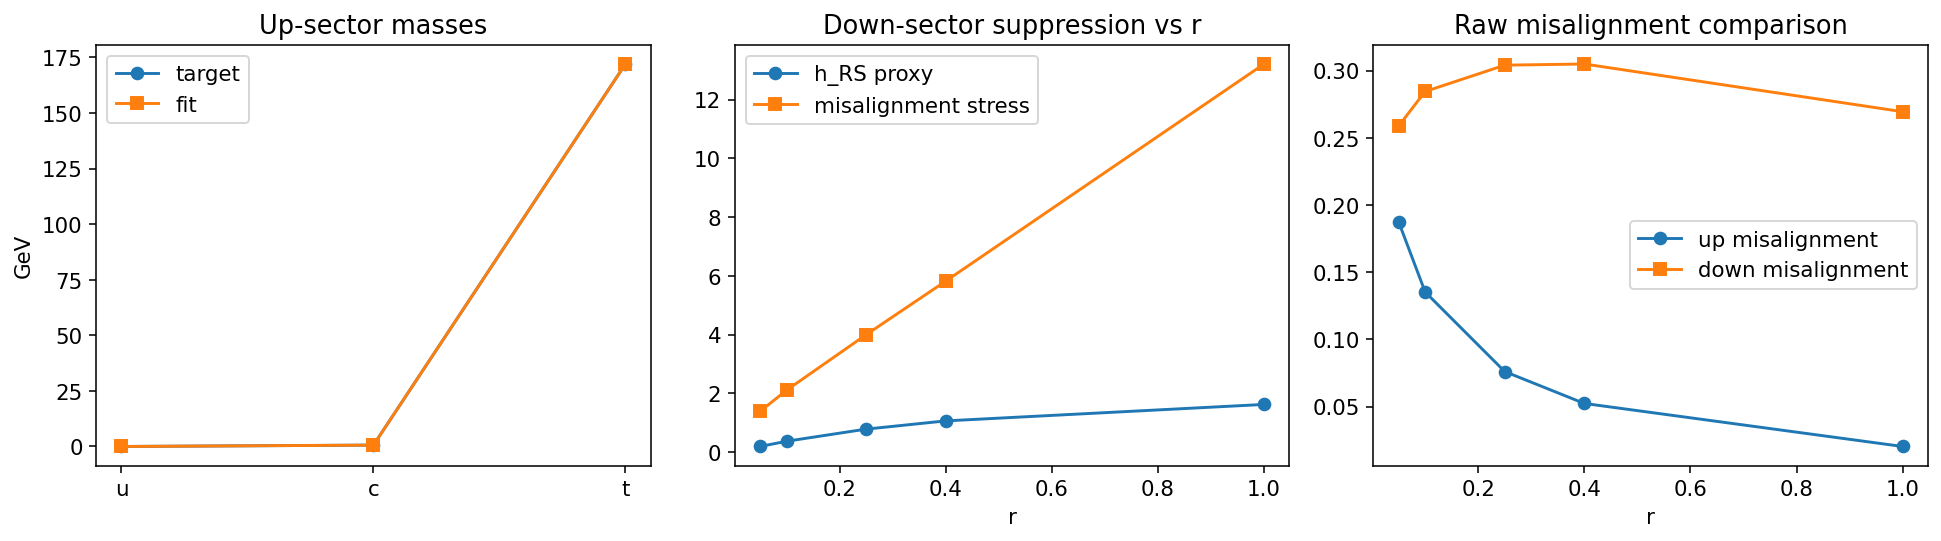

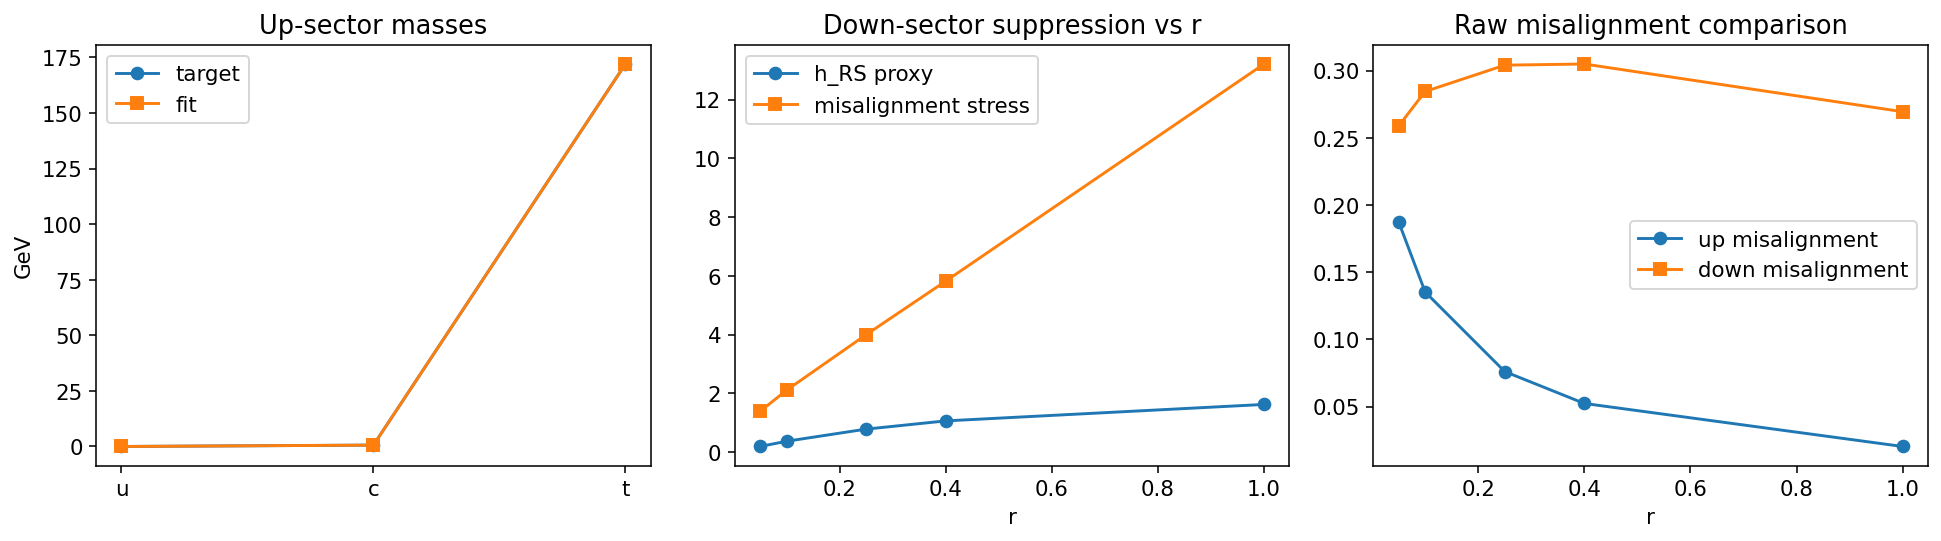

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

labels = ['u', 'c', 't']
axes[0].plot(labels, bench['target_masses_up'], marker='o', label='target')
axes[0].plot(labels, bench['fit_masses_up'], marker='s', label='fit')
axes[0].set_title('Up-sector masses')
axes[0].set_ylabel('GeV')
axes[0].legend()

axes[1].plot(sweep['r_values'], sweep['down_proxy'], marker='o', label='h_RS proxy')
axes[1].plot(sweep['r_values'], sweep['down_to_up_misalignment_ratio'], marker='s', label='misalignment stress')
axes[1].set_title('Down-sector suppression vs r')
axes[1].set_xlabel('r')
axes[1].legend()

axes[2].plot(sweep['r_values'], sweep['up_misalignment'], marker='o', label='up misalignment')
axes[2].plot(sweep['r_values'], sweep['down_misalignment'], marker='s', label='down misalignment')
axes[2].set_title('Raw misalignment comparison')
axes[2].set_xlabel('r')
axes[2].legend()

fig.tight_layout()
fig